In [ ]:
import sys, os
from pathlib import Path

def _find_project_root():
    for parent in [Path.cwd(), *Path.cwd().parents]:
        if (parent / ".git").exists():
            return parent
    raise RuntimeError("Could not find project root (.git not found)")

root = str(_find_project_root())
os.chdir(root)
if root not in sys.path:
    sys.path.insert(0, root)

/tmp/ipykernel_2339176/3276934523.py:91: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  scatter2 = ax.scatter(


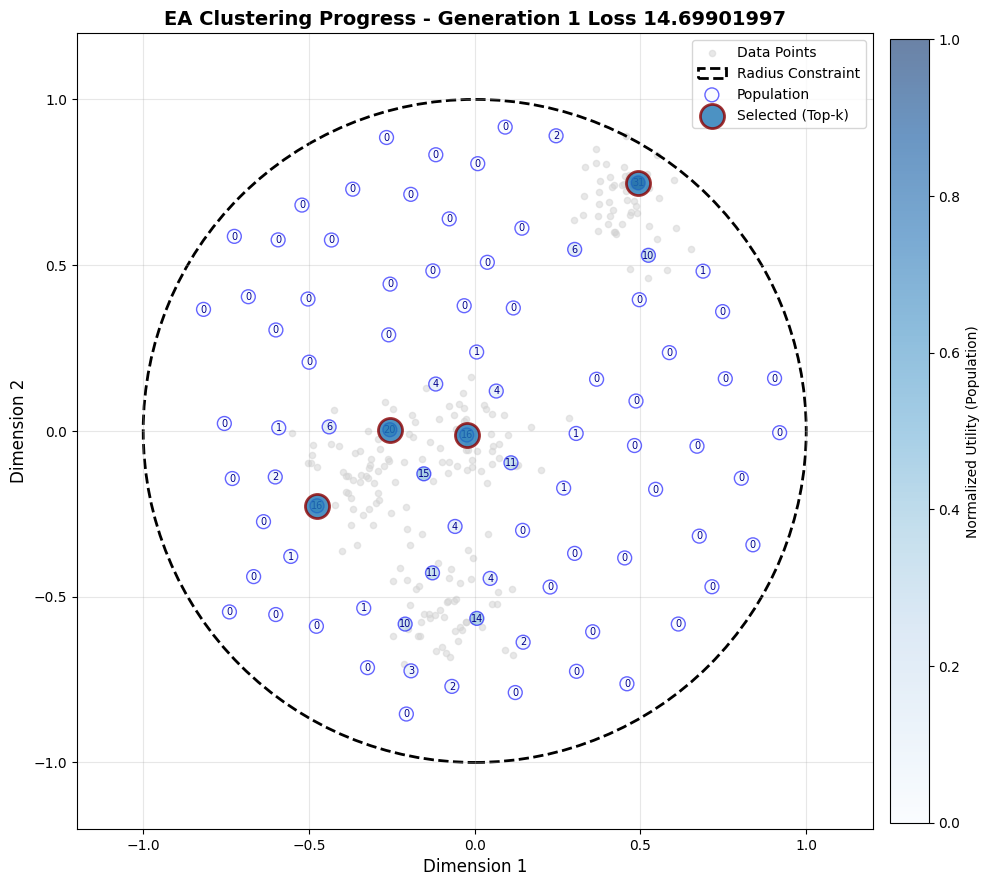

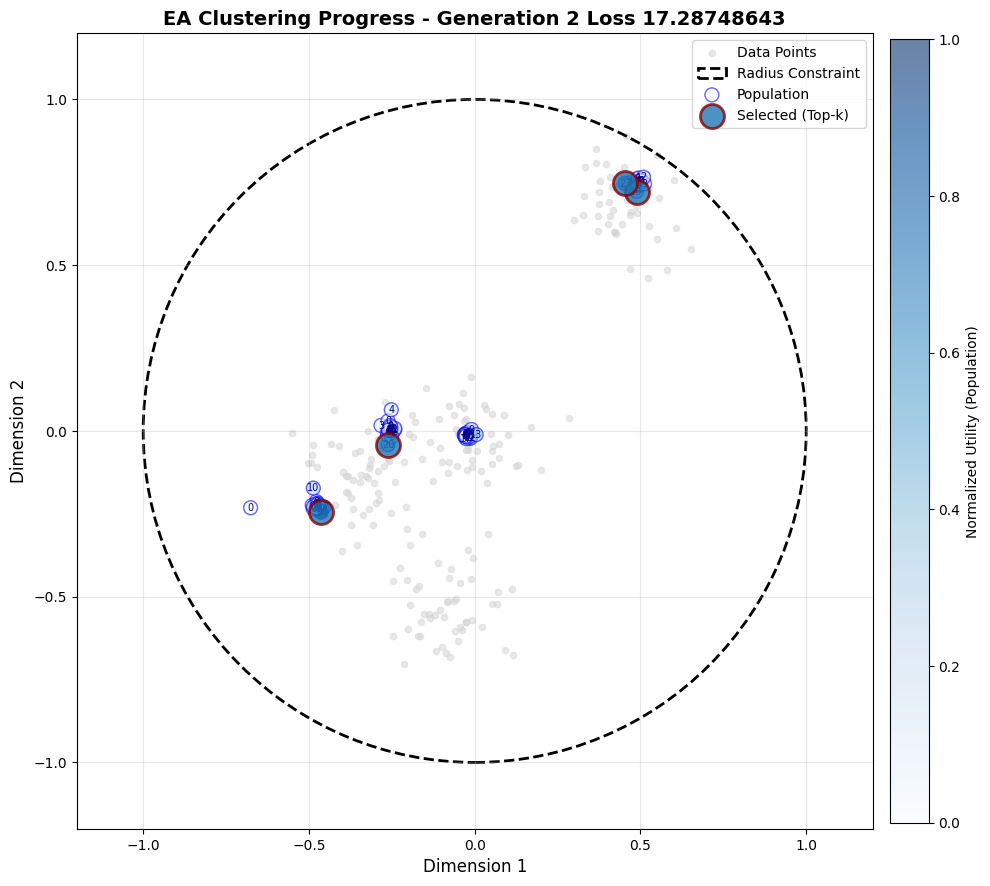

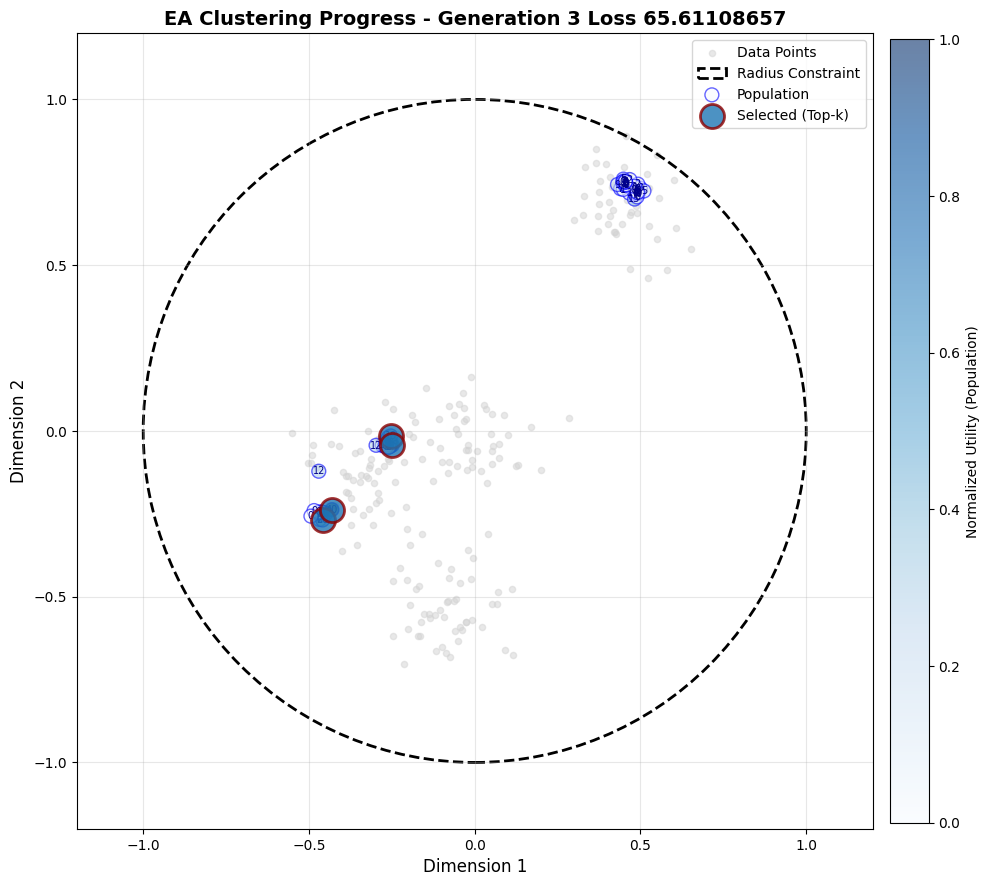

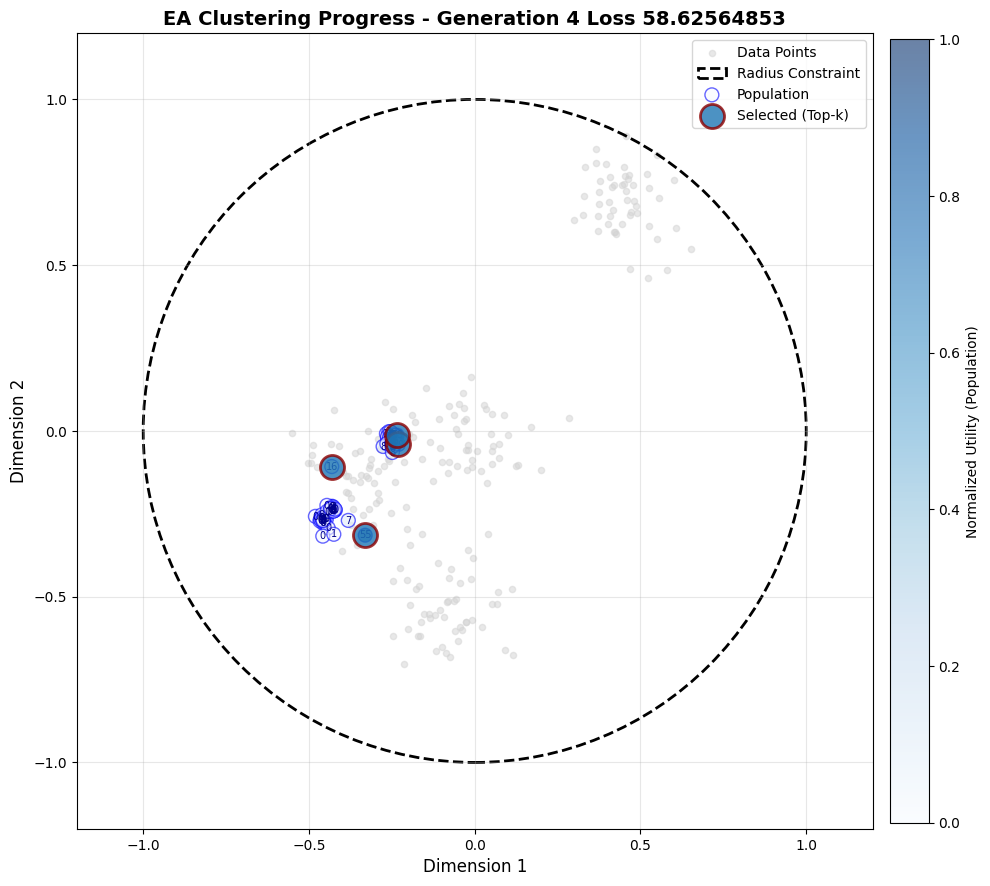

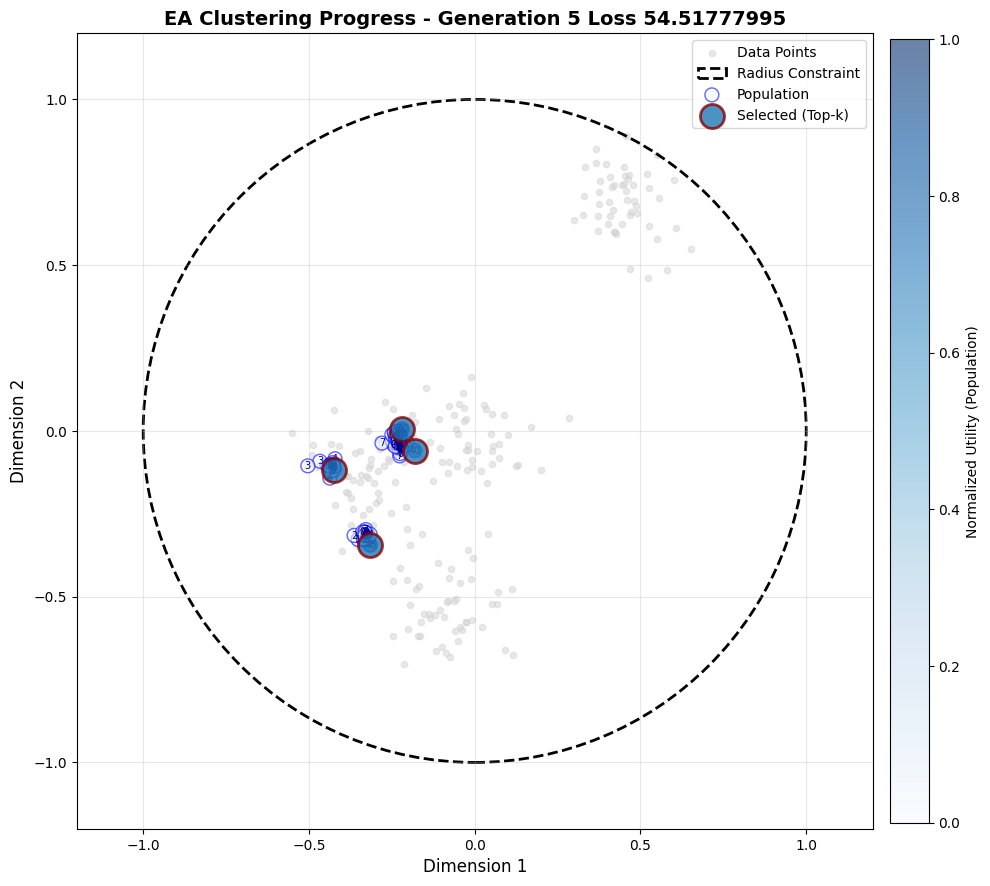

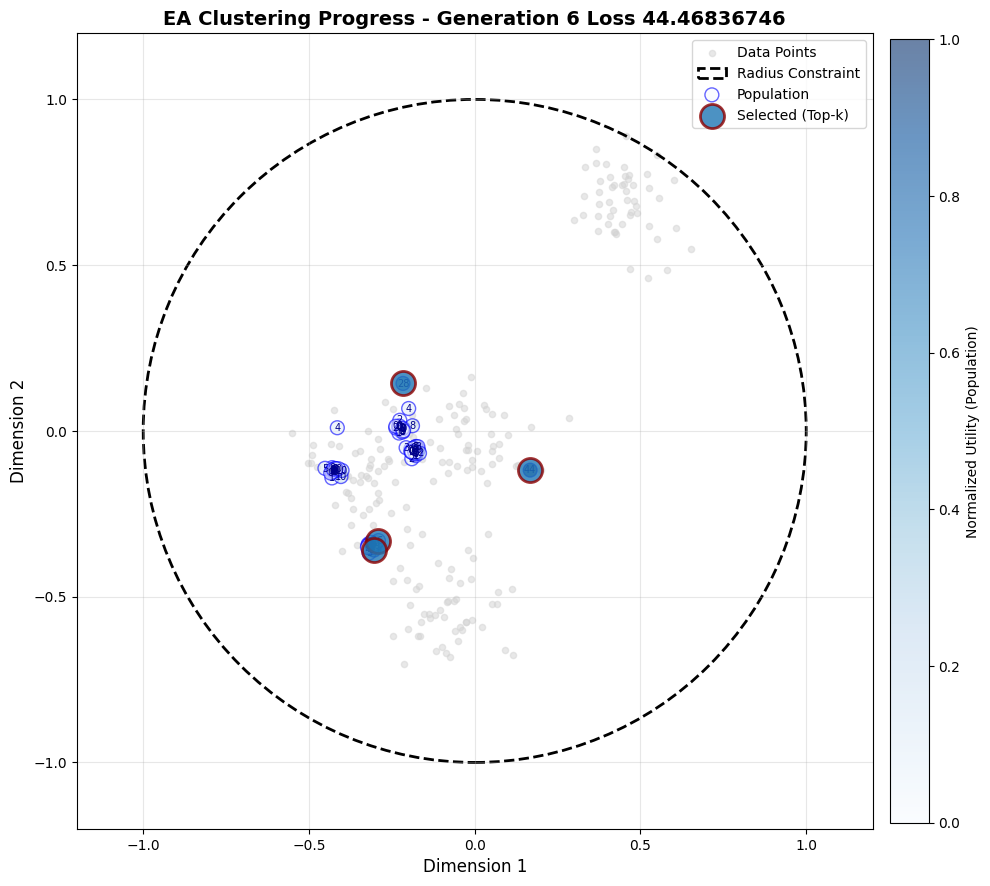

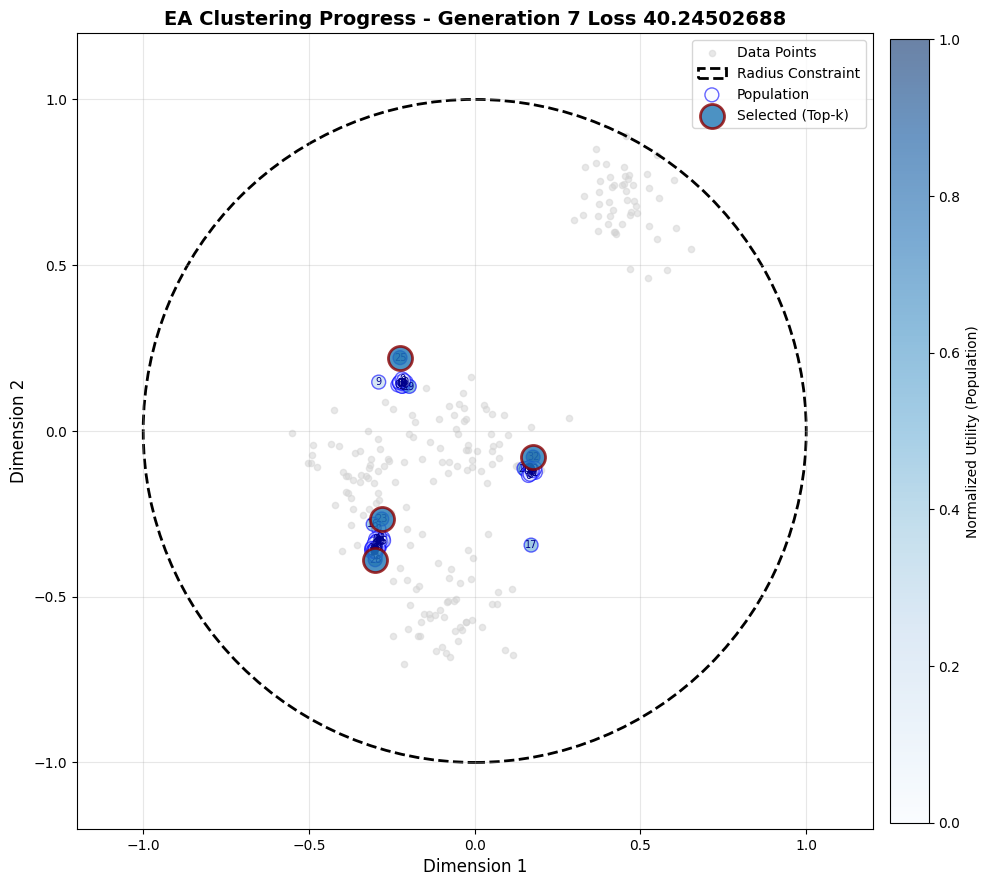

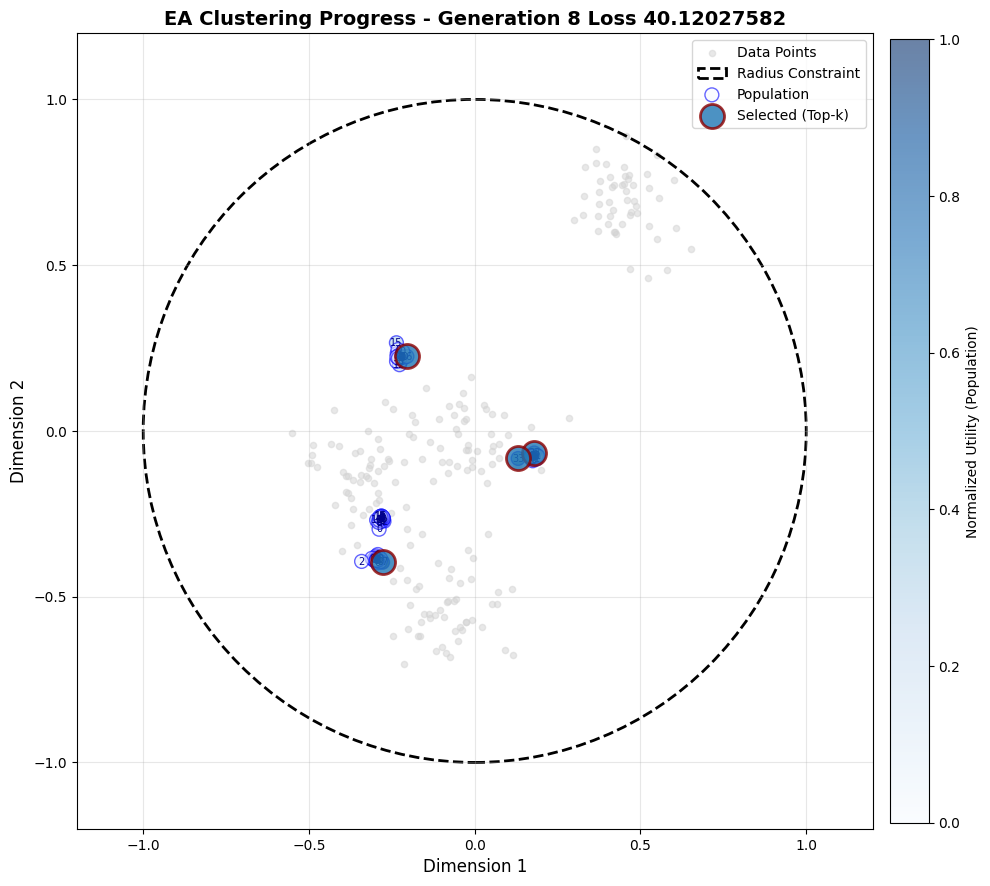

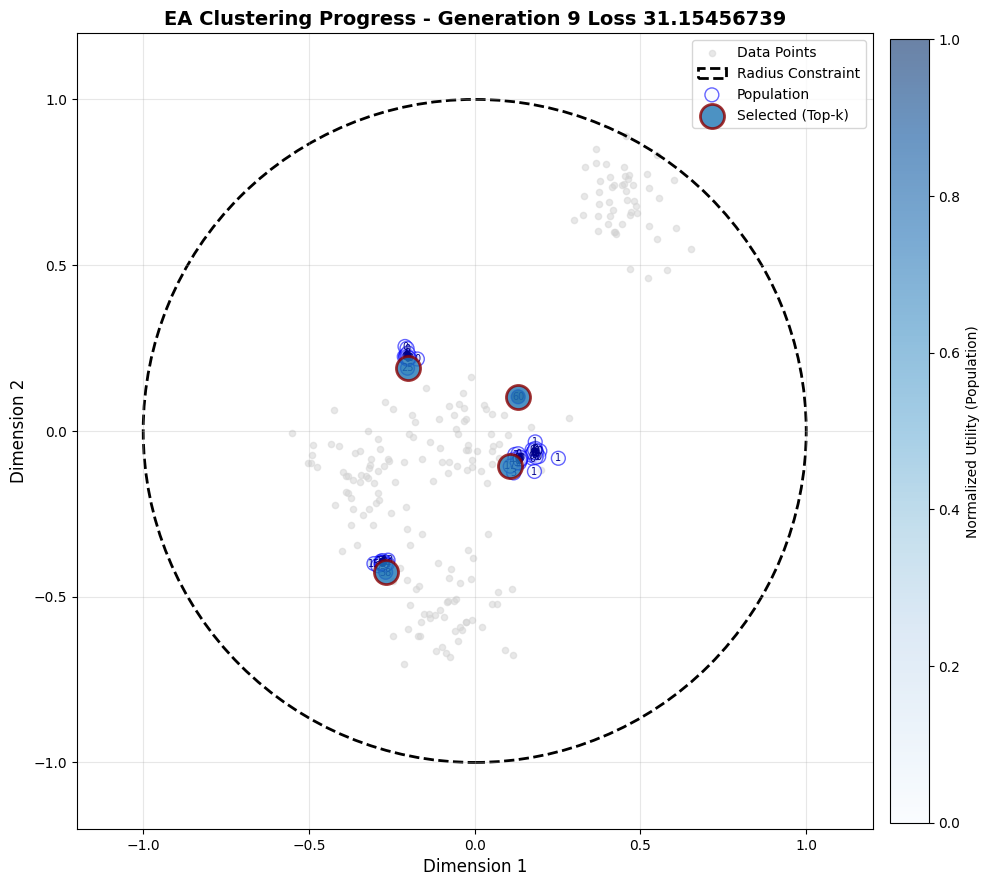

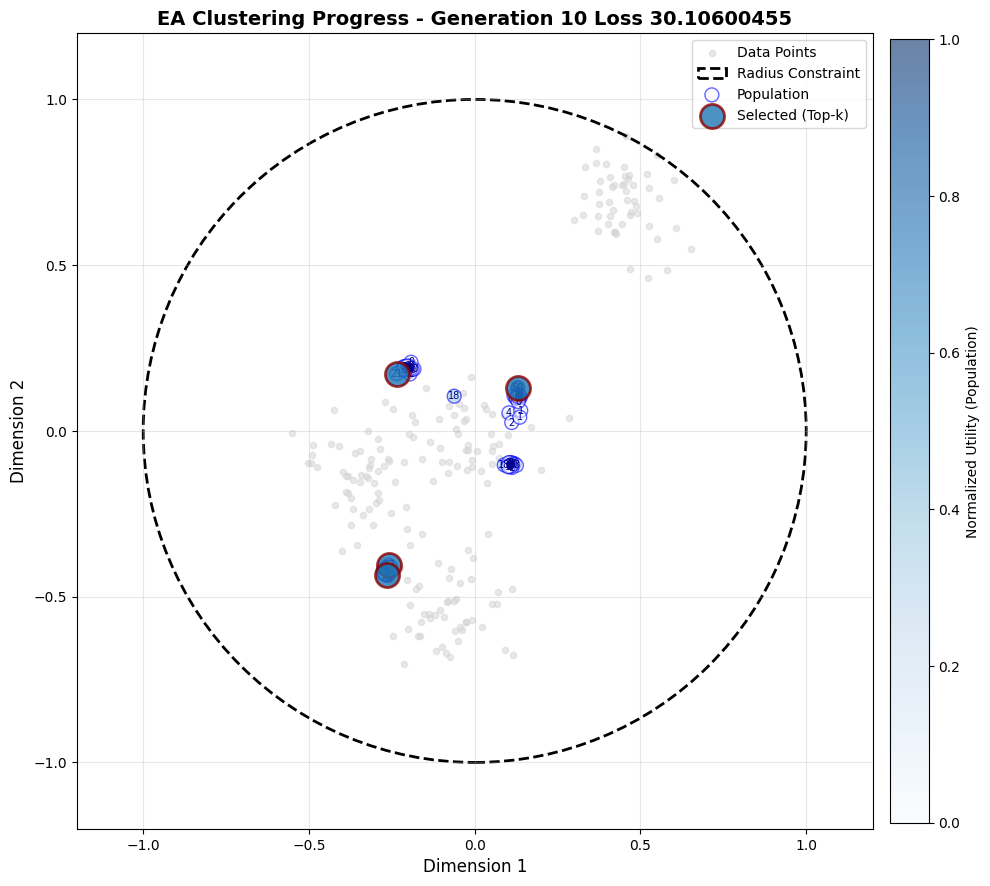

In [ ]:

from sklearn.datasets import make_blobs
import matplotlib.pyplot as plt
from matplotlib.patches import Circle
from clustering import clustering_params
from src.helpers import *
import numpy as np
from src.pe_means_main import pe_means
dataset, _ =  make_blobs(n_samples=200, n_features=2, centers=4, random_state=1)
dataset, r, _ = dataset_preprocess(dataset)
dataset_object = clustering_params.Data(
        datapoints=dataset,
        radius=r
    )
k=4
privacy_param_2d = None
ea_params = PE_PARAMS.copy()
loss, centers, history = pe_means(
    k,
    dataset_object,
    ea_params,
    privacy_param_2d,
)



# Visualization Function
def plot_generation(data, generation_data, k, title="EA Clustering"):
    """Plot a single generation with population, utility, and selected points."""
    fig, ax = plt.subplots(1, 1, figsize=(10, 10))
    
    population = generation_data['population']
    utility = generation_data['utility']
    top_samples = generation_data['top_samples']
    gen = generation_data['generation']
    
    # Plot data points (small gray dots)
    ax.scatter(data.datapoints[:, 0], data.datapoints[:, 1], 
               c='lightgray', s=20, alpha=0.5, label='Data Points', zorder=1)
    
    # Plot circle representing the radius constraint
    circle = Circle((0, 0), data.radius, fill=False, color='black', 
                    linestyle='--', linewidth=2, label='Radius Constraint')
    ax.add_patch(circle)
    
    # Normalize utility for color mapping
    utility_norm = (utility - utility.min()) / (utility.max() - utility.min() + 1e-10)
    
    # Create a mask for selected vs non-selected points

    
    # Plot population points (smaller, with coolmap colors)
    scatter1 = ax.scatter(
        population[:, 0], 
        population[:, 1],
        c=utility_norm,
        cmap='Blues',
        s=100,
        alpha=0.6,
        edgecolors='blue',
        linewidth=1,
        label='Population',
        zorder=2
    )
        
    # Annotate non-selected points with utility values
    for i in range(len(population)):
        ax.annotate(f'{utility[i]:.0f}', 
                    (population[i, 0], population[i, 1]),
                    fontsize=7, 
                    ha='center',
                    va='center',
                    color='darkblue',
                    weight='normal',
                    zorder=3)
    
    # Plot selected population points (larger, with warm colors)
   
    scatter2 = ax.scatter(
        top_samples[:, 0], 
        top_samples[:, 1],
        cmap='Reds',
        s=300,
        alpha=0.8,
        edgecolors='darkred',
        linewidth=2,
        label='Selected (Top-k)',
        zorder=4
    )
    

    
    ax.set_xlim(-data.radius * 1.2, data.radius * 1.2)
    ax.set_ylim(-data.radius * 1.2, data.radius * 1.2)
    ax.set_aspect('equal')
    ax.grid(True, alpha=0.3)
    ax.set_xlabel('Dimension 1', fontsize=12)
    ax.set_ylabel('Dimension 2', fontsize=12)
    ax.set_title(f'{title} - Generation {gen+1} Loss {generation_data["loss"]:.8f}', fontsize=14, weight='bold')
    ax.legend(loc='upper right', fontsize=10)
    
    # Add colorbar for utility
  
    cbar1 = plt.colorbar(scatter1, ax=ax, pad=0.02, fraction=0.046)
    cbar1.set_label('Normalized Utility (Population)', fontsize=10)
    
    plt.tight_layout()
    return fig

# Plot selected generations (e.g., 1, 3, 5, 7, 9, 10)
generations_to_plot = list(range(10))
for gen_idx in generations_to_plot:
    if gen_idx < len(history):
        fig = plot_generation(dataset_object, history[gen_idx], k, 
                            title="EA Clustering Progress")
        plt.show()


Running EA with top_k selection...
Running EA with k_means selection...


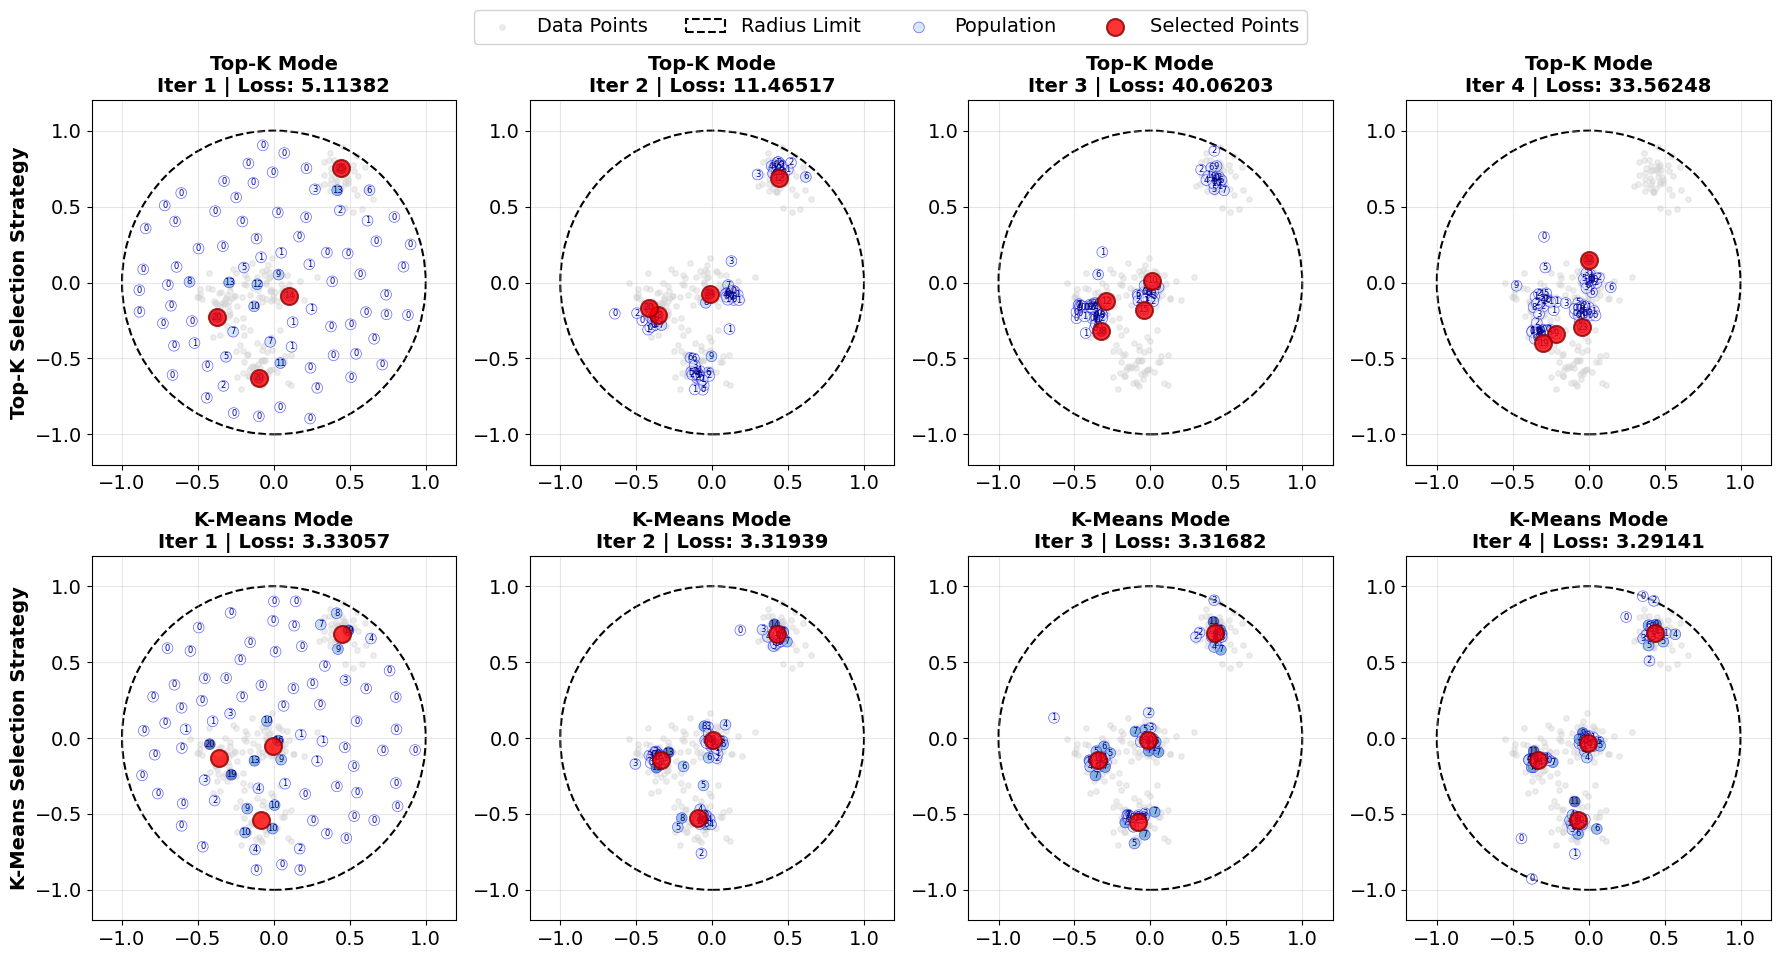

In [ ]:
from sklearn.datasets import make_blobs
import matplotlib.pyplot as plt
from matplotlib.patches import Circle
from clustering import clustering_params
from src.helpers import *
import numpy as np
from src.pe_means_main import pe_means
import copy

np.random.seed(42)
# 1. Setup Dataset
dataset, _ = make_blobs(n_samples=200, n_features=2, centers=4, random_state=1)
dataset, r, _ = dataset_preprocess(dataset)
dataset_object = clustering_params.Data(
    datapoints=dataset,
    radius=r
)
k = 4
privacy_param_2d = None

# Base parameters
base_ea_params = {
    'L': 20, 
    'num_gen': 10,
    'init_mode': 'sphere_packing', 
    'var_scale': 0.05, 
    'levy_beta': 1.75,
    'L_reduce_threshold': 1.0,
    'L_reduce_factor': 0.5,
    'run_id' : 0
}

# 2. Run EA for 'top_k' selection mode
ea_params_top_k = copy.deepcopy(base_ea_params)
ea_params_top_k['select_mode'] = 'top_k'
print("Running EA with top_k selection...")
_, _, history_top_k = pe_means(k, dataset_object, ea_params_top_k, privacy_param_2d)

# 3. Run EA for 'k_means' selection mode
ea_params_kmeans = copy.deepcopy(base_ea_params)
ea_params_kmeans['select_mode'] = 'k_means'
print("Running EA with k_means selection...")
_, _, history_kmeans = pe_means(k, dataset_object, ea_params_kmeans, privacy_param_2d)


# 4. Streamlined Visualization Function (No internal legends or colorbars)
def plot_generation_to_ax(ax, data, generation_data, title="EA Clustering"):
    """Plot a single generation onto an axis and return the population scatter object."""
    population = generation_data['population']
    utility = generation_data['utility']
    top_samples = generation_data['top_samples']
    gen = generation_data['generation']
    
    
    # Plot data points (small gray dots)
    ax.scatter(data.datapoints[:, 0], data.datapoints[:, 1], 
               c='lightgray', s=15, alpha=0.4, label='Data Points', zorder=1)
    
    # Plot circle representing the radius constraint
    circle = Circle((0, 0), data.radius, fill=False, color='black', 
                    linestyle='--', linewidth=1.5, label='Radius Limit')
    ax.add_patch(circle)
    
    # Normalize utility for color mapping
    utility_norm = (utility - utility.min()) / (utility.max() - utility.min() + 1e-10)
    
    # Plot population points
    scatter_pop = ax.scatter(
        population[:, 0], 
        population[:, 1],
        c=utility_norm,
        cmap='Blues',
        s=60,
        alpha=0.6,
        edgecolors='blue',
        linewidth=0.5,
        label='Population',
        zorder=2
    )
        
    # Annotate population points with utility values
    for i in range(len(population)):
        ax.annotate(f'{utility[i]:.0f}', 
                    (population[i, 0], population[i, 1]),
                    fontsize=6, 
                    ha='center',
                    va='center',
                    color='darkblue',
                    zorder=3)
    
    # Plot selected population points
    ax.scatter(
        top_samples[:, 0], 
        top_samples[:, 1],
        c='red',
        s=150,
        alpha=0.8,
        edgecolors='darkred',
        linewidth=1.5,
        label='Selected Points',
        zorder=4
    )
    
    # Axis configuration
    ax.set_xlim(-data.radius * 1.2, data.radius * 1.2)
    ax.set_ylim(-data.radius * 1.2, data.radius * 1.2)
    ax.set_aspect('equal')
    ax.grid(True, alpha=0.3)
    
    ax.set_title(f'{title}\nIter {gen+1} | Loss: {generation_data["loss"]:.5f}', weight='bold')
    
    return scatter_pop

#set global font size for all text to 14
plt.rcParams.update({
    'font.size': 14,           # base font size
    'axes.titlesize': 14,      # axes title
    'axes.labelsize': 14,      # x/y axis labels
    'xtick.labelsize': 14,     # x tick labels
    'ytick.labelsize': 14,     # y tick labels
    'legend.fontsize': 14,     # legend text
    'figure.titlesize': 14,    # figure suptitle
})
# 5. Create Subplot Grid (2 rows x 4 columns)
fig, axes = plt.subplots(2, 4, figsize=(20, 10))

mappable = None

# Plot first 4 generations
for col_idx in range(4):
    # Row 1: top_k approach
    if col_idx < len(history_top_k):
        mappable = plot_generation_to_ax(
            axes[0, col_idx], 
            dataset_object, 
            history_top_k[col_idx], 
            title="Top-K Mode"
        )
    
    # Row 2: k_means approach
    if col_idx < len(history_kmeans):
        plot_generation_to_ax(
            axes[1, col_idx], 
            dataset_object, 
            history_kmeans[col_idx], 
            title="K-Means Mode"
        )

# Add row labels for easier distinction
axes[0, 0].set_ylabel('Top-K Selection Strategy', weight='bold')
axes[1, 0].set_ylabel('K-Means Selection Strategy', weight='bold')

# 6. Global Shared Elements
# Extract handles and labels from the very first subplot to build the unified legend
handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', ncol=4, framealpha=0.9)

# # Add a single shared colorbar on the right side of the entire grid matrix
# if mappable is not None:
#     cbar = fig.colorbar(mappable, ax=axes, orientation='vertical', fraction=0.015, pad=0.04, shrink=0.8)
#     cbar.set_label('Normalized Utility (Population)', fontsize=11, weight='bold')
#     cbar.ax.tick_params(labelsize=9)

# Adjust spacing manually to avoid collisions with the global legend and colorbar
plt.subplots_adjust(top=0.90, bottom=0.08, left=0.08, right=0.92, hspace=0.25, wspace=0.2)

plt.savefig(
    'plots/vote_split.pdf', 
    format='pdf', 
    bbox_inches='tight', 
    transparent=False
)
plt.show()
# Close the plot to free up memory
plt.close()